## Test Runs on Train Gen. Methods

In [1]:
import os
import sys
import json
import subprocess
import gc
import torch
from pathlib import Path
from collections import Counter


In [9]:
!pip install chess cairosvg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 5.3 MB/s eta 0:00:00


In [2]:
CONFIG = {
    "colab": True,
    "branch": "main",
    "repo_name": "BigDataAndTextMiningProject",
    "repo_owner": "Aivon99",
    "repo_dir": "/content/BigDataAndTextMiningProject",
}



In [3]:
if CONFIG["colab"]:
    repo_dir = Path(CONFIG["repo_dir"])
    if repo_dir.exists():
        subprocess.run(["rm", "-rf", str(repo_dir)], check=True)

    auth_url = "https://"
    repo_url = f"{auth_url}github.com/{CONFIG['repo_owner']}/{CONFIG['repo_name']}.git"

    result = subprocess.run(
        ["git", "clone", "--single-branch", "--branch", CONFIG["branch"], repo_url, str(repo_dir)],
        capture_output=True, text=True
    )
    assert result.returncode == 0, f"Git clone failed: {result.stderr}"

    os.chdir(repo_dir)
    sys.path.insert(0, str(repo_dir))
else:
    repo_dir = Path(".").resolve()
    os.chdir(repo_dir)
    sys.path.insert(0, str(repo_dir))

REPO_ROOT = Path(".").resolve()
print("Setup Complete. REPO_ROOT:", REPO_ROOT)

Setup Complete. REPO_ROOT: /content/BigDataAndTextMiningProject


In [10]:
# Cell 1
# Basic imports

from pathlib import Path

repo_root = Path("/content/BigDataAndTextMiningProject")
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / "src" / "data"))

from src.data.generation import (
    build_sample,
    generate_dataset,
    ChessDatasetGenerator
)

from src.data.utilities import (
    load_lichess_csv
)

In [11]:
# Cell 2
# Example FEN positions

fens = [

    # Starting position
    "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",

    # Midgame
    "r2qkbnr/ppp1pppp/2n5/3p4/3P1B2/2N4P/PPP1PP2/R2QKBNR w KQkq - 0 1",

    # Endgame
    "8/8/8/2k5/8/5K2/8/8 w - - 0 1"
]

len(fens)

3

In [12]:
# Cell 3
# Test single sample generation

sample = build_sample(
    fen=fens[0],
    sample_id="debug_sample",
    image_size=512,
    task="fen"
)

sample["metadata"]

{'sample_id': 'debug_sample',
 'task': 'fen',
 'fen': 'rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1',
 'prompt': '\nYou are a specialized model for chessboard understanding.\n\nYour task is to generate the FEN representation\nof the given chessboard image.\n\nReturn ONLY the FEN string.\n',
 'target': 'rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1',
 'image_size': 512,
 'patch_order': 'row_major',
 'patch_size': 16}

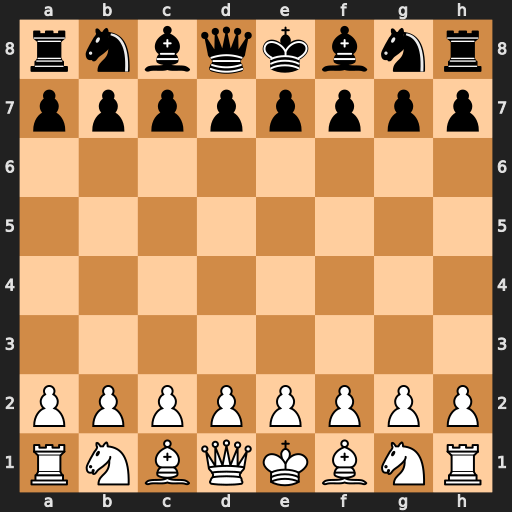

In [13]:
# Cell 4
# Visualize generated image

sample["image"]

In [14]:
# Cell 5
# Save one sample to disk

output_dir = Path("debug_dataset")

sample = build_sample(
    fen=fens[1],
    sample_id="saved_example",
    output_dir=output_dir,
    image_size=512,
    task="fen"
)

print("Saved successfully.")

Saved successfully.


In [15]:
# Cell 6
# Check saved structure

for path in output_dir.rglob("*"):
    print(path)

debug_dataset/saved_example
debug_dataset/saved_example/board.png
debug_dataset/saved_example/metadata.json


In [16]:
# Cell 7
# Batch dataset generation

generate_dataset(
    fens=fens,
    output_dir="batch_dataset",
    image_size=512,
    task="fen"
)

print("Batch dataset generated.")

100%|██████████| 3/3 [00:00<00:00,  9.24it/s]

Batch dataset generated.


In [17]:
# Cell 8
# Inspect generated dataset

dataset_dir = Path("batch_dataset")

samples = sorted(dataset_dir.iterdir())

print(f"Number of samples: {len(samples)}")

samples[:3]

Number of samples: 3


[PosixPath('batch_dataset/sample_000000'),
 PosixPath('batch_dataset/sample_000001'),
 PosixPath('batch_dataset/sample_000002')]

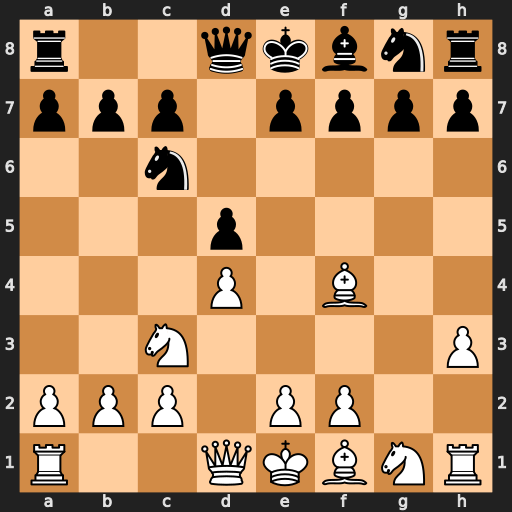

In [18]:
# Cell 9
# Open one saved image manually

from PIL import Image

img = Image.open(
    "batch_dataset/sample_000001/board.png"
)

img

In [19]:
# Cell 10
# Inspect metadata JSON

import json

with open(
    "batch_dataset/sample_000001/metadata.json"
) as f:

    metadata = json.load(f)

metadata

{'sample_id': 'sample_000001',
 'task': 'fen',
 'fen': 'r2qkbnr/ppp1pppp/2n5/3p4/3P1B2/2N4P/PPP1PP2/R2QKBNR w KQkq - 0 1',
 'prompt': '\nYou are a specialized model for chessboard understanding.\n\nYour task is to generate the FEN representation\nof the given chessboard image.\n\nReturn ONLY the FEN string.\n',
 'target': 'r2qkbnr/ppp1pppp/2n5/3p4/3P1B2/2N4P/PPP1PP2/R2QKBNR w KQkq - 0 1',
 'image_size': 512,
 'patch_order': 'row_major',
 'patch_size': 16}

sample_000000


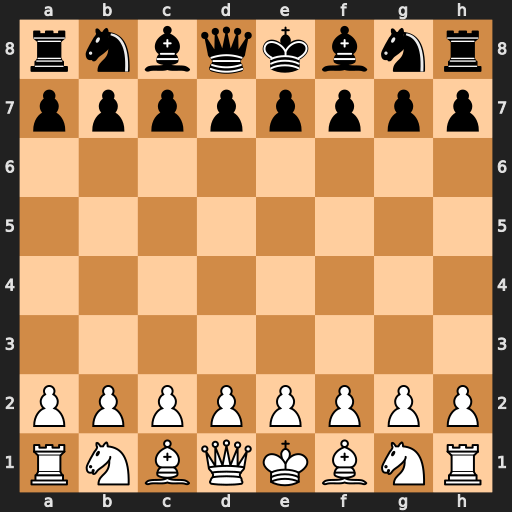

sample_000001


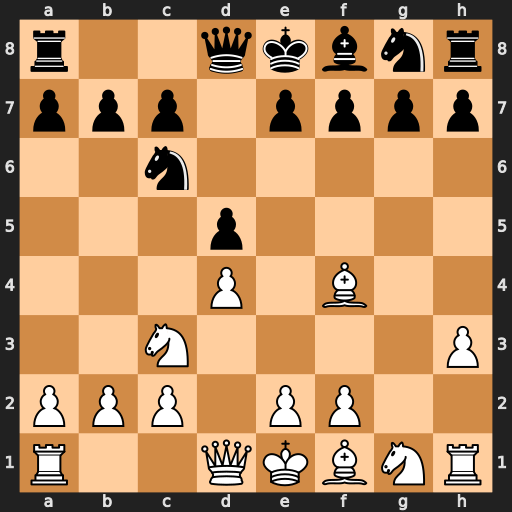

In [20]:
# Cell 11
# Test generator mode

generator = ChessDatasetGenerator(
    fens=fens,
    image_size=512,
    task="fen"
)

for idx, sample in enumerate(generator):

    print(sample["metadata"]["sample_id"])

    display(sample["image"])

    if idx == 1:
        break

In [21]:
    # Cell 12
if True:
    # Test loading Lichess CSV

    csv_path = "lichess_db_puzzle.csv"

    df = load_lichess_csv(
        csv_path=csv_path,
        max_samples=5
    )

    df.head()
    # Cell 13
    # Extract FENs from Lichess dataframe

    lichess_fens = df["FEN"].tolist()

    lichess_fens[:3]
    # Cell 14
    # Generate dataset from Lichess sample

    generate_dataset(
        fens=lichess_fens,
        output_dir="lichess_dataset",
        image_size=512,
        task="fen"
    )

    print("Lichess dataset generated.")
    # Cell 15
    # Visualize one generated Lichess sample

    img = Image.open(
        "lichess_dataset/sample_000000/board.png"
    )

    img# Cell 16
    # Inspect metadata of generated Lichess sample

    with open(
        "lichess_dataset/sample_000000/metadata.json"
    ) as f:

        metadata = json.load(f)

    metadata

IndentationError: expected an indented block after 'if' statement on line 2 (3798846530.py, line 5)